In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
os.environ["PMIX_MCA_gds"]="hash"

# Import useful packages
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.toolbox_metal import math_and_overrides
from qiskit_metal.qlibrary.core import QComponent
from collections import OrderedDict

# To create plots after geting solution data.
import matplotlib.pyplot as plt
import numpy as np

# Packages for the simple design
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight
from qiskit_metal.qlibrary.tlines.pathfinder import RoutePathfinder
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.terminations.short_to_ground import ShortToGround
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee

# Set up chip design as planar, multiplanar also available
design = designs.DesignPlanar({}, overwrite_enabled=True)

# Set up chip dimensions
design.chips.main.size.size_x = '4.8mm'
design.chips.main.size.size_y = '2.4mm'
design.chips.main.size.size_z = '500um'
design.chips.main.size.center_x = '0mm'
design.chips.main.size.center_y = '-1mm'

# Resonator and feedline gap width (W) and center conductor width (S) are set to 50 Ohm
design.variables['cpw_width'] = '10 um' #S
design.variables['cpw_gap'] = '6 um' #W

# Create GUI
gui = MetalGUI(design)

# Lauchpad 1
x1 = '-2mm'
y1 = '0mm'
launch_options1 = dict(chip='main', pos_x=x1, pos_y=y1, orientation='360', lead_length='30um', pad_height='103um',
                      pad_width='103um', pad_gap='60um')
LP1 = LaunchpadWirebond(design, 'LP1', options = launch_options1)

# Launchpad 2
x2 = '2mm'
y1 = '0mm'
launch_options2 = dict(chip='main', pos_x=x2, pos_y=y1, orientation='180', lead_length='30um', pad_height='103um',
                      pad_width='103um', pad_gap='60um')
LP2 = LaunchpadWirebond(design, 'LP2', options = launch_options2)

# Using path finder to connect the two launchpads
TL = RoutePathfinder(design, 'TL', options = dict(chip='main', trace_width ='10um',
                                            trace_gap ='6um',
                                            fillet='90um',
                                            hfss_wire_bonds = True,
                                            lead=dict(end_straight='0.1mm'),
                                            pin_inputs=Dict(
                                                start_pin=Dict(
                                                    component='LP1',
                                                    pin='tie'),
                                                end_pin=Dict(
                                                    component='LP2',
                                                    pin='tie')
                                            )))


######################
# lambda/4 resonator1#
######################
otg1 = OpenToGround(design, 'otg1', options=dict(chip='main', pos_x='-0.2mm',  pos_y='-40um', orientation = 180))
stg1 = ShortToGround(design, 'stg1', options=dict(chip='main', pos_x='0mm',  pos_y='-1.35mm', orientation = -90))

# Use RouteMeander to fix the total length of the resonator
res1 = RouteMeander(design, 'resonator1',  Dict(
        trace_width ='10um',
        trace_gap ='6um',
        total_length='3.7mm',
        hfss_wire_bonds = False,
        fillet='99.9 um',
        lead = dict(start_straight='300um'),
        pin_inputs=Dict(
        start_pin=Dict(component='otg1', pin='open'),
        end_pin=Dict(component='stg1', pin='short')), ))

# rebuild the GUI
gui.rebuild()

In [2]:
from SQDMetal.PALACE.Eigenmode_Simulation import PALACE_Eigenmode_Simulation
from SQDMetal.Utilities.Materials import MaterialInterface, MaterialConductor

#Eigenmode Simulation Options
user_defined_options = {
                 "mesh_refinement":  0,                             #refines mesh in PALACE - essetially divides every mesh element in half
                 "dielectric_material": "silicon",                  #choose dielectric material - 'silicon' or 'sapphire'
                 "starting_freq": 5e9,                              #starting frequency in Hz
                 "number_of_freqs": 1,                              #number of eigenmodes to find
                 "solns_to_save": 1,                                #number of electromagnetic field visualizations to save
                 "solver_order": 2,                                 #increasing solver order increases accuracy of simulation, but significantly increases sim time
                 "solver_tol": 1.0e-7,                              #error residual tolerance foriterative solver
                 "solver_maxits": 200,                              #number of solver iterations
                 "fillet_resolution":12,                            #number of vertices per quarter turn on a filleted path
                 "palace_dir":"/home/ruiz/repo/spack/opt/spack/linux-zen3/palace-develop-blpbtxe43ne2or3yo7gou6ycmdwdxuzl/bin/palace",#"PATH/TO/PALACE/BINARY",
                 "num_cpus": 8                                     #number of cpus to use in the simulation
                }

#Creat the Palace Eigenmode simulation
eigen_sim = PALACE_Eigenmode_Simulation(name ='res_eigen_test',                              #name of simulation
                                        metal_design = design,                                      #feed in qiskit metal design
                                        sim_parent_directory = "",            #choose directory where mesh file, config file and HPC batch file will be saved
                                        mode = 'simPC',                                               #choose simulation mode 'HPC' or 'simPC'
                                        meshing = 'GMSH',                                         #choose meshing 'GMSH' or 'COMSOL'
                                        user_options = user_defined_options,                        #provide options chosen above
                                        create_files = True)                                        #create mesh, config and HPC batch files

#Add in metals from layer 1 of the design file
eigen_sim.add_metallic(1)

#Add in ground plane for simulation
eigen_sim.add_ground_plane()

#Add in lumped element ports on launcher pads for 50 Ohm matching
eigen_sim.create_port_CPW_on_Launcher('LP1', 20e-6)
eigen_sim.create_port_CPW_on_Launcher('LP2', 20e-6)

#Fine mesh the resonator, launch apds and transmission line
eigen_sim.fine_mesh_components(['TL', 'resonator1', 'LP1', 'LP2'], min_size=16e-6, max_size=100e-6, taper_dist_min=10e-6, metals_only=False)

#Sets up the lossy interfaces for MA, SA and MS interfaces
eigen_sim.setup_EPR_interfaces(metal_air=MaterialInterface('Aluminium-Vacuum'), substrate_air=MaterialInterface('Silicon-Vacuum'), substrate_metal=MaterialInterface('Silicon-Aluminium'))

#Only works in v0.14
# eigen_sim.set_farfield(ff_type='conductor', ff_material=MaterialConductor("OFHC"), ff_plane='z_neg')

#Prepares the mesh file and config file
eigen_sim.prepare_simulation()

Error   : Gmsh has not been initialized
Error   : Gmsh has not been initialized


In [3]:
#run the simulation
eigen_sim.run()

>> /usr/bin/mpirun -n 8 /home/ruiz/repo/spack/opt/spack/linux-zen3/palace-develop-blpbtxe43ne2or3yo7gou6ycmdwdxuzl/bin/palace-x86_64.bin res_eigen_test.json

_____________     _______
_____   __   \____ __   /____ ____________
____   /_/  /  __ ` /  /  __ ` /  ___/  _ \
___   _____/  /_/  /  /  /_/  /  /__/  ___/
  /__/     \___,__/__/\___,__/\_____\_____/


--> Warning!
Output folder is not empty; program will overwrite content! (outputFiles)
Git changeset ID: 3b8c020
Running with 8 MPI processes
Device configuration: cpu
Memory configuration: host-std
libCEED backend: /cpu/self/xsmm/blocked

Added 2438 elements in 2 iterations of local bisection for under-resolved interior boundaries
Added 5075 duplicate vertices for interior boundaries in the mesh
Added 12471 duplicate boundary elements for interior boundaries in the mesh
Added 1859 boundary elements for material interfaces to the mesh

Characteristic length and time scales:
 Lc = 5.760e-03 m, tc = 1.921e-02 ns
Finished partitioning

array([[1.00000000e+00, 7.83847464e+00, 4.03479976e-05, 9.71358568e+04,
        5.84694534e-13, 8.80683555e-07]])

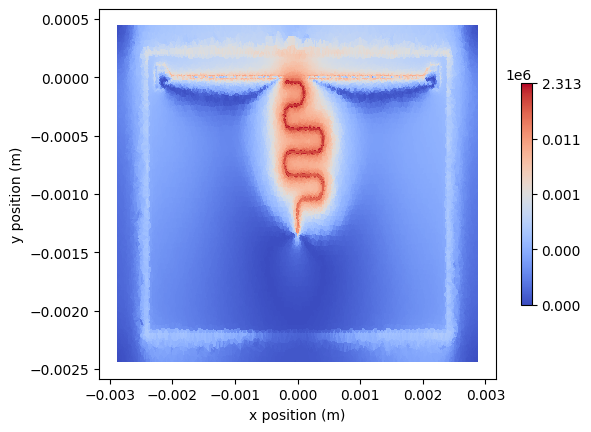

In [4]:
%matplotlib inline
pvdtu = eigen_sim.retrieve_field_plots()
leSlice = pvdtu.get_data_slice(0)
leSlice.plot(np.linalg.norm(leSlice.get_data('E_real'), axis=1), 'coolwarm', True);